In [1]:
import pandas as pd

path = 'dati/cubi_STATPOP_01.csv'

# Leggo solo la prima riga per capire codifica e separatore
try:
    with open(path, encoding='utf-8') as f:
        prima = f.readline()
    enc = 'utf-8'
except UnicodeDecodeError:
    with open(path, encoding='latin-1') as f:
        prima = f.readline()
    enc = 'latin-1'

sep = ';' if prima.count(';') > prima.count(',') else ','
print("Codifica:", enc, "| Separatore:", repr(sep))

# Ora carico con il motore veloce
df = pd.read_csv(path, sep=sep, encoding=enc)

print("Righe e colonne:", df.shape)
print()
print("Colonne:")
for c in df.columns:
    print(" -", c)

Codifica: latin-1 | Separatore: ';'
Righe e colonne: (819720, 6)

Colonne:
 - Statistiche
 - Sesso
 - Nazionalità
 - Cantone_Distretto_Comune
 - Anno
 - Popolazione


In [2]:
print("=== STATISTICHE DISPONIBILI ===")
for s in df['Statistiche'].unique():
    print(" -", s)

print()
print("=== ANNI ===")
print("dal", df['Anno'].min(), "al", df['Anno'].max())

print()
print("=== SESSO ===")
print(df['Sesso'].unique())

print()
print("=== NAZIONALITÀ ===")
print(df['Nazionalità'].unique())

print()
print("=== QUANTI COMUNI/DISTRETTI ===")
print(df['Cantone_Distretto_Comune'].nunique(), "valori diversi")

=== STATISTICHE DISPONIBILI ===
 - Stato della popolazione  al 1° gennaio
 - Nato vivo
 - Decesso
 - Incremento naturale
 - Immigrazione inclusi i cambiamenti del tipo di popolazione
 - Arrivo intercantonale
 - Arrivo intracantonale
 - Emigrazione
 - Partenza intercantonale
 - Partenza intracantonale
 - Saldo migratorio inclusi i cambiamenti del tipo di popolazione
 - Cambiamento del tipo di popolazione
 - Acquisizione della nazionalità  svizzera
 - Cambiamento di sesso all'ufficio di stato civile (entrata)
 - Cambiamento di sesso all'ufficio di stato civile (uscita)
 - Divergenza statistica
 - Stato della popolazione al 31 dicembre
 - Variazione

=== ANNI ===
dal 1981 al 2024

=== SESSO ===
<StringArray>
['Sesso - totale', 'Uomo', 'Donna']
Length: 3, dtype: str

=== NAZIONALITÀ ===
<StringArray>
['Nazionalità (categoria) - totale', 'Svizzera', 'Straniera']
Length: 3, dtype: str

=== QUANTI COMUNI/DISTRETTI ===
115 valori diversi


In [3]:
print("SESSO:")
print(list(df['Sesso'].unique()))

print()
print("NAZIONALITÀ:")
print(list(df['Nazionalità'].unique()))

print()
print("PRIMI 5 VALORI DI Cantone_Distretto_Comune:")
print(list(df['Cantone_Distretto_Comune'].unique()[:5]))

SESSO:
['Sesso - totale', 'Uomo', 'Donna']

NAZIONALITÀ:
['Nazionalità (categoria) - totale', 'Svizzera', 'Straniera']

PRIMI 5 VALORI DI Cantone_Distretto_Comune:
['Ticino', 'Distretto di Bellinzona', '5001 Arbedo-Castione', '5002 Bellinzona', '5003 Cadenazzo']


In [4]:
# Tengo solo: Ticino intero, totale sessi, totale nazionalità
# e le due statistiche che mi servono
ticino = df[
    (df['Cantone_Distretto_Comune'] == 'Ticino') &
    (df['Sesso'] == 'Sesso - totale') &
    (df['Nazionalità'] == 'Nazionalità (categoria) - totale') &
    (df['Statistiche'].isin([
        'Incremento naturale',
        'Saldo migratorio inclusi i cambiamenti del tipo di popolazione'
    ]))
]

# Trasformo da formato lungo a largo: una riga per anno, una colonna per statistica
tab = ticino.pivot_table(
    index='Anno',
    columns='Statistiche',
    values='Popolazione'
)

# Nomi corti
tab.columns = ['saldo_naturale', 'saldo_migratorio']

print("Righe:", len(tab))
tab.head(10)

Righe: 44


,saldo_naturale,saldo_migratorio
Anno,,
1981,-228.0,3388.0
1982,-105.0,2590.0
1983,-71.0,1016.0
1984,-136.0,1486.0
1985,-146.0,1879.0
1986,-103.0,2062.0
1987,-41.0,1468.0
1988,-142.0,2125.0
1989,6.0,2387.0


In [5]:
# Crescita totale = naturale + migratoria
tab['crescita_totale'] = tab['saldo_naturale'] + tab['saldo_migratorio']

# Quanto pesa la migrazione, in percentuale, sulla crescita di ogni anno
tab['peso_migrazione_%'] = (tab['saldo_migratorio'] / tab['crescita_totale'] * 100).round(1)

print("=== TOTALI 1981-2024 ===")
print("Saldo naturale cumulato: ", int(tab['saldo_naturale'].sum()))
print("Saldo migratorio cumulato:", int(tab['saldo_migratorio'].sum()))
print("Crescita totale:         ", int(tab['crescita_totale'].sum()))

print()
print("=== ANNI CON SALDO NATURALE NEGATIVO ===")
neg = tab[tab['saldo_naturale'] < 0]
print(len(neg), "anni su", len(tab))

print()
print("=== ULTIMI 10 ANNI ===")
print(tab.tail(10))

=== TOTALI 1981-2024 ===
Saldo naturale cumulato:  -5692
Saldo migratorio cumulato: 104038
Crescita totale:          98346

=== ANNI CON SALDO NATURALE NEGATIVO ===
25 anni su 44

=== ULTIMI 10 ANNI ===
      saldo_naturale  saldo_migratorio  crescita_totale  peso_migrazione_%
Anno                                                                      
2015          -337.0            1762.0           1425.0              123.6
2016          -182.0            2432.0           2250.0              108.1
2017          -456.0            -232.0           -688.0               33.7
2018          -596.0             153.0           -443.0              -34.5
2019          -744.0            -733.0          -1477.0               49.6
2020         -1561.0            1187.0           -374.0             -317.4
2021          -562.0            1868.0           1306.0              143.0
2022         -1102.0            3077.0           1975.0              155.8
2023         -1098.0            4738.0         

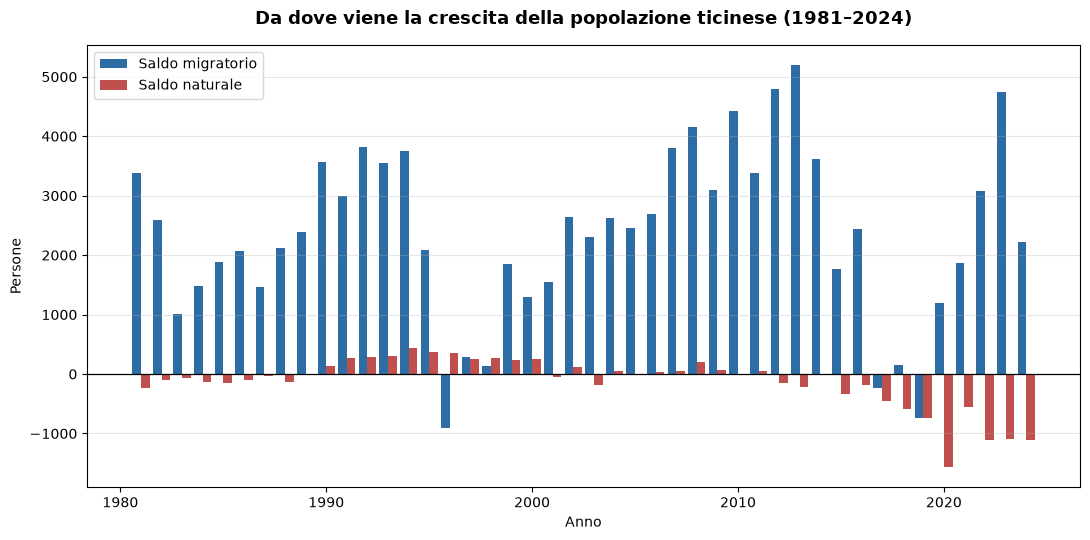

In [7]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array(tab.index)
w = 0.42

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.bar(x - w/2, tab['saldo_migratorio'], width=w,
       label='Saldo migratorio', color='#2E6DA4')
ax.bar(x + w/2, tab['saldo_naturale'], width=w,
       label='Saldo naturale', color='#C0504D')

ax.axhline(0, color='black', linewidth=0.9)

ax.set_title('Da dove viene la crescita della popolazione ticinese (1981–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Anno')
ax.set_ylabel('Persone')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('grafici/saldi_1981_2024.png', dpi=150, bbox_inches='tight')
plt.show()

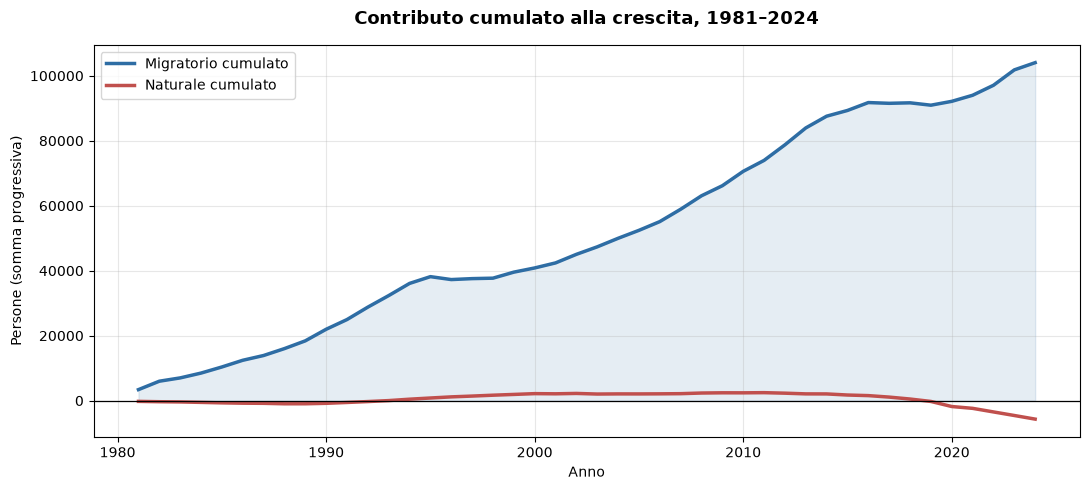

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

cum_nat = tab['saldo_naturale'].cumsum()
cum_mig = tab['saldo_migratorio'].cumsum()

ax.plot(tab.index, cum_mig, linewidth=2.5,
        color='#2E6DA4', label='Migratorio cumulato')
ax.plot(tab.index, cum_nat, linewidth=2.5,
        color='#C0504D', label='Naturale cumulato')
ax.fill_between(tab.index, 0, cum_mig, color='#2E6DA4', alpha=0.12)

ax.axhline(0, color='black', linewidth=0.9)

ax.set_title('Contributo cumulato alla crescita, 1981–2024',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Anno')
ax.set_ylabel('Persone (somma progressiva)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('grafici/cumulato_1981_2024.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Bar(
    x=tab.index, y=tab['saldo_migratorio'],
    name='Migratorio',
    marker=dict(color='#2E6DA4', line=dict(width=0)),
    hovertemplate='Migratorio: <b>%{y:+,.0f}</b><extra></extra>'
))

fig.add_trace(go.Bar(
    x=tab.index, y=tab['saldo_naturale'],
    name='Naturale',
    marker=dict(color='#C0504D', line=dict(width=0)),
    hovertemplate='Naturale: <b>%{y:+,.0f}</b><extra></extra>'
))

fig.update_layout(
    title=dict(
        text="<b>Da dove viene la crescita della popolazione ticinese</b>"
             "<br><span style='font-size:13px;color:#6B6B6B'>"
             "Saldo naturale e migratorio, 1981–2024</span>",
        x=0.02, xanchor='left', y=0.93,
        font=dict(size=21, color='#1B3A5C')
    ),
    barmode='group',
    bargap=0.25,
    bargroupgap=0.05,
    hovermode='x unified',
    hoverlabel=dict(bgcolor='white', bordercolor='#DDDDDD',
                    font=dict(size=13, color='#2B2B2B')),
    legend=dict(orientation='h', yanchor='bottom', y=1.0,
                xanchor='right', x=1, font=dict(size=13)),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Carlito, Calibri, sans-serif',
              size=13, color='#2B2B2B'),
    height=580,
    margin=dict(t=110, b=60, l=70, r=40)
)

anni = list(tab.index)
tick_vals = [anni[0]] + [a for a in anni if a % 5 == 0 and a not in (anni[0], anni[-1])] + [anni[-1]]

fig.update_xaxes(
    title=None, showgrid=False,
    showline=True, linecolor='#CCCCCC',
    ticks='outside', tickcolor='#CCCCCC',
    tickmode='array', tickvals=tick_vals
)

fig.update_yaxes(
    title=dict(text='Persone', font=dict(size=13, color='#6B6B6B')),
    showgrid=True, gridcolor='#EFEFEF',
    zeroline=True, zerolinecolor='#333333', zerolinewidth=1.2,
    tickformat=',.0f'
)

fig.write_html('grafico_interattivo.html', include_plotlyjs='cdn')
fig.show()

In [12]:
cum_nat = tab['saldo_naturale'].cumsum()
cum_mig = tab['saldo_migratorio'].cumsum()

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=tab.index, y=cum_mig,
    name='Migratorio', mode='lines',
    line=dict(color='#2E6DA4', width=3),
    fill='tozeroy', fillcolor='rgba(46,109,164,0.10)',
    hovertemplate='Migratorio: <b>%{y:+,.0f}</b><extra></extra>'
))

fig2.add_trace(go.Scatter(
    x=tab.index, y=cum_nat,
    name='Naturale', mode='lines',
    line=dict(color='#C0504D', width=3),
    hovertemplate='Naturale: <b>%{y:+,.0f}</b><extra></extra>'
))

fig2.update_layout(
    title=dict(
        text="<b>Contributo cumulato alla crescita</b>"
             "<br><span style='font-size:13px;color:#6B6B6B'>"
             "Somma progressiva dei saldi, 1981–2024</span>",
        x=0.02, xanchor='left', y=0.93,
        font=dict(size=21, color='#1B3A5C')
    ),
    hovermode='x unified',
    hoverlabel=dict(bgcolor='white', bordercolor='#DDDDDD',
                    font=dict(size=13, color='#2B2B2B')),
    legend=dict(orientation='h', yanchor='bottom', y=1.0,
                xanchor='right', x=1, font=dict(size=13)),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Carlito, Calibri, sans-serif',
              size=13, color='#2B2B2B'),
    height=560,
    margin=dict(t=110, b=60, l=80, r=40)
)

fig2.update_xaxes(
    title=None, showgrid=False,
    showline=True, linecolor='#CCCCCC',
    ticks='outside', tickcolor='#CCCCCC',
    tickmode='array', tickvals=tick_vals
)

fig2.update_yaxes(
    title=dict(text='Persone (somma progressiva)',
               font=dict(size=13, color='#6B6B6B')),
    showgrid=True, gridcolor='#EFEFEF',
    zeroline=True, zerolinecolor='#333333', zerolinewidth=1.2,
    tickformat=',.0f'
)

fig2.write_html('grafico_cumulato.html', include_plotlyjs='cdn')
fig2.show()